In [1]:
from tess_cloud import *
from tess_asteroid_ml.utils import *
from astropy.wcs import WCS
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt

/Users/jorgemarpa/.pyenv/versions/tess-asteroids-v2/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/jorgemarpa/.lightkurve/cache. Please move all the files in the legacy directory /Users/jorgemarpa/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
url = 'https://archive.stsci.edu/missions/tess/ffi/s0002/2018/253/1-1/tess2018253025941-s0002-1-1-0121-s_ffic.fits'

In [3]:
ti = TessImage(url)
ti

TessImage("tess2018253025941-s0002-1-1-0121-s_ffic.fits")

In [4]:
from tess_locator import *

In [5]:
with fits.open(url) as ffi:
    wcs = WCS(ffi[1])
    date_obs = Time([ffi[0].header["DATE-OBS"], ffi[0].header["DATE-END"]])

Set MJD-END to 58371.150792 from DATE-END'. [astropy.wcs.wcs]


In [6]:
col_2d, row_2d, f2d = load_ffi_image(
                "TESS",
                url,
                1,
                None,
                [0, 0],
                return_coords=True,
            )
ra_2d, dec_2d = wcs.all_pix2world(np.vstack([col_2d.ravel(), row_2d.ravel()]).T, 0.0).T
ra_2d = ra_2d.reshape(col_2d.shape)
dec_2d = dec_2d.reshape(col_2d.shape)

In [7]:
ffi_coord = SkyCoord(ra_2d*u.deg, dec_2d*u.deg, frame='icrs', obstime=date_obs.mean().isot)

In [8]:
time_off = (date_obs[0] - 1000 * u.day).isot
time_on = date_obs.mean().isot

In [9]:
time_on, time_off

('2018-09-10T03:22:08.469', '2015-12-15T03:07:09.480')

In [10]:
ffi_coord[1000, 1000]

<SkyCoord (ICRS): (ra, dec) in deg
    (348.30644836, -31.51271704)>

In [11]:
crd = locate(ffi_coord[1000, 1000], time=time_on, aberrate=True)
crd

List of 1 coordinates
 ↳[TessCoord(sector=2, camera=1, ccd=1, column=1045.2, row=1001.0, time=2018-09-10 03:22:08)]

In [14]:
TessCoord(sector=3, camera=1, ccd=4, column=1747.25387013423, row=1240.1978118830734)

TessCoord(sector=3, camera=1, ccd=4, column=1747.3, row=1240.2, time=None)

In [15]:
type(crd[0])

tess_locator.tesscoord.TessCoord

In [16]:
crd[0].is_observed()

AttributeError: 'TessCoord' object has no attribute 'is_observed'

In [17]:
img = crd.list_images()[0]
img

AttributeError: 'TessCoordList' object has no attribute 'list_images'

In [18]:
img.url

NameError: name 'img' is not defined

In [20]:
from tess_cloud import *

In [21]:
ffi_coord[1000, 1000]

<SkyCoord (ICRS): (ra, dec) in deg
    (348.30644836, -31.51271704)>

In [25]:
stamp2 = cutout(
    target=ffi_coord[1000, 1000],
    shape=(5,5),
    sector=2,
    author="spoc",
    provider="mast",
    images=100,
)

List of 1543 images
 ↳[TessImage("tess2018235142941-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018235145941-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018235152941-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018235155941-s0002-1-1-0121-s_ffic.fits")
   ...
   TessImage("tess2018262225940-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018262225941-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018262232940-s0002-1-1-0121-s_ffic.fits")
   TessImage("tess2018262232941-s0002-1-1-0121-s_ffic.fits")]


In [26]:
stamp2.meta 

OrderedDict([('SIMPLE', True), ('BITPIX', 8), ('NAXIS', 0), ('EXTEND', True), ('TELESCOP', 'TESS'), ('ORIGIN', 'tess_cloud'), ('CREATOR', 'tess_cloud.targetpixelfile'), ('DATE', '2023-12-07')])

<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

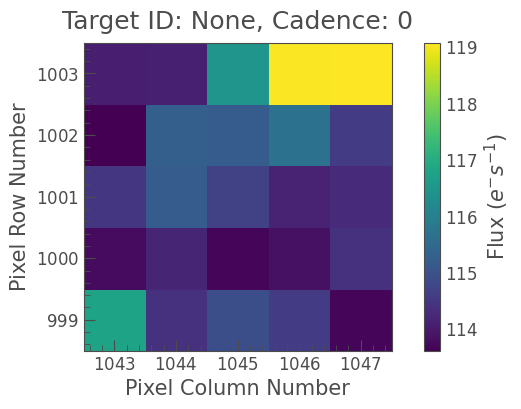

In [28]:
stamp2.plot()

In [ ]:
3 Juno (A804 RA)

In [31]:
aster = cutout_asteroid(
    target="A804 RA",
    sector=5,
    images=100,
)

Could not find requested sector: -1 in the available sector pointing data


In [35]:
aster.shape

(610, 10, 10)

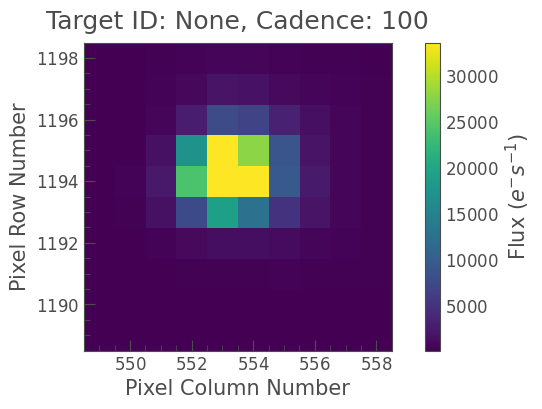

In [37]:
aster.plot(frame=100)
plt.show()